In [1]:
import jetfuelburn
from jetfuelburn import ureg

In [2]:
from jetfuelburn.reducedorder import sacchi_etal
from jetfuelburn.reducedorder import yanto_etal

In [3]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sweep parameters
weightloss_coeffs = [0.08, 0.10]  # body-weight reduction for ozempic users
ozempic_fractions = [0.04, 0.06, 0.08, 0.10, 0.12]  # share of passengers on ozempic

# Fixed flight / aircraft parameters
pax_max = 440
loadfactor = 0.835  # Montlaur load factor (used in sacchi)
pax_nmbr = 260  # absolute pax count (used in yanto)
weight_per_pax = 100 * ureg.kg
R = 7000 * ureg.km
CO2_FACTOR = 3.16  # kg CO2 per kg jet fuel
FUEL_COST_PER_KG = 1.4  # USD per kg (1400 USD per 1000 kg)

In [4]:
# Baselines (no ozempic)
fuel_sacchi_base = sacchi_etal.calculate_fuel_consumption(
    year=2024,
    pax_max=pax_max,
    pax=pax_max * loadfactor,
    R=R,
)
fuel_yanto_base = yanto_etal.calculate_fuel_consumption(
    acft="A333",
    R=R,
    PL=pax_nmbr * weight_per_pax,
)

records = []
for wl, oz in itertools.product(weightloss_coeffs, ozempic_fractions):
    # sacchi: ozempic reduces effective pax weight → modelled as fewer equivalent pax
    pax_oz = pax_max * loadfactor * (1 - wl * oz)
    fuel_sacchi_oz = sacchi_etal.calculate_fuel_consumption(
        year=2024,
        pax_max=pax_max,
        pax=pax_oz,
        R=R,
    )
    sacchi_fuel_diff = (fuel_sacchi_base - fuel_sacchi_oz).to("kg").magnitude
    sacchi_co2_diff = sacchi_fuel_diff * CO2_FACTOR
    sacchi_cost_diff = sacchi_fuel_diff * FUEL_COST_PER_KG

    # yanto: ozempic users weigh less → mixed payload
    weight_oz = weight_per_pax * (1 - wl)
    payload_oz = pax_nmbr * ((1 - oz) * weight_per_pax + oz * weight_oz)
    fuel_yanto_oz = yanto_etal.calculate_fuel_consumption(
        acft="A333",
        R=R,
        PL=payload_oz,
    )
    yanto_fuel_diff = (fuel_yanto_base - fuel_yanto_oz).to("kg").magnitude
    yanto_co2_diff = yanto_fuel_diff * CO2_FACTOR
    yanto_cost_diff = yanto_fuel_diff * FUEL_COST_PER_KG

    records.append(
        {
            "weightloss_coeff": wl,
            "people_on_ozempic": oz,
            "sacchi_fuel_diff_kg": sacchi_fuel_diff,
            "sacchi_co2_diff_kg": sacchi_co2_diff,
            "sacchi_cost_diff_usd": sacchi_cost_diff,
            "yanto_fuel_diff_kg": yanto_fuel_diff,
            "yanto_co2_diff_kg": yanto_co2_diff,
            "yanto_cost_diff_usd": yanto_cost_diff,
        }
    )

df = pd.DataFrame(records)
print(df.to_string(index=False))

 weightloss_coeff  people_on_ozempic  sacchi_fuel_diff_kg  sacchi_co2_diff_kg  sacchi_cost_diff_usd  yanto_fuel_diff_kg  yanto_co2_diff_kg  yanto_cost_diff_usd
             0.08               0.04            54.231173          171.370507             75.923642             27.3728          86.498048             38.32192
             0.08               0.06            81.347422          257.057854            113.886391             41.0592         129.747072             57.48288
             0.08               0.08           108.464113          342.746597            151.849758             54.7456         172.996096             76.64384
             0.08               0.10           135.581246          428.436737            189.813744             68.4320         216.245120             95.80480
             0.08               0.12           162.698821          514.128275            227.778350             82.1184         259.494144            114.96576
             0.10               0.04    

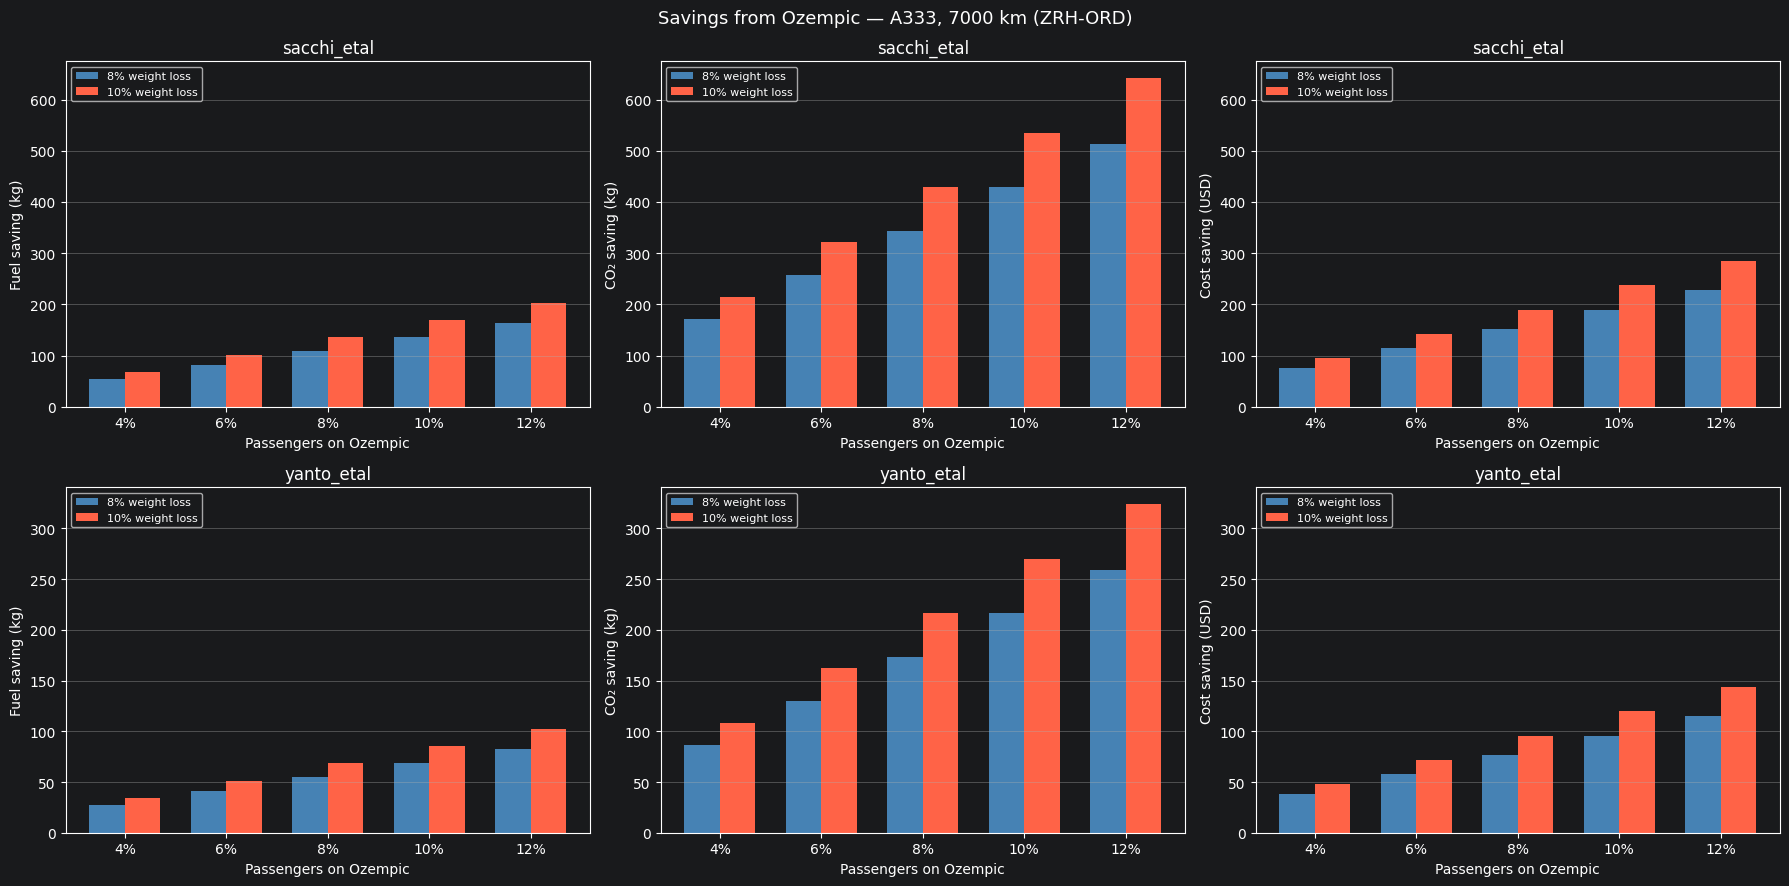

In [5]:
x = np.arange(len(ozempic_fractions))
width = 0.35
labels = [f"{int(oz * 100)}%" for oz in ozempic_fractions]
colors = ["steelblue", "tomato"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey="row")
fig.suptitle("Savings from Ozempic — A333, 7000 km (ZRH-ORD)", fontsize=13)

metrics = [
    (
        "sacchi_etal",
        "sacchi_fuel_diff_kg",
        "sacchi_co2_diff_kg",
        "sacchi_cost_diff_usd",
    ),
    ("yanto_etal", "yanto_fuel_diff_kg", "yanto_co2_diff_kg", "yanto_cost_diff_usd"),
]

for row_idx, (model, fuel_col, co2_col, cost_col) in enumerate(metrics):
    for col_idx, (metric, ylabel) in enumerate(
        [
            (fuel_col, "Fuel saving (kg)"),
            (co2_col, "CO₂ saving (kg)"),
            (cost_col, "Cost saving (USD)"),
        ]
    ):
        ax = axes[row_idx][col_idx]
        for i, wl in enumerate(weightloss_coeffs):
            subset = df[df["weightloss_coeff"] == wl].sort_values("people_on_ozempic")
            ax.bar(
                x + (i - 0.5) * width,
                subset[metric].values,
                width,
                label=f"{int(wl * 100)}% weight loss",
                color=colors[i],
            )
        ax.set_title(f"{model}")
        ax.set_ylabel(ylabel)
        ax.set_xlabel("Passengers on Ozempic")
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.tick_params(labelleft=True)
        ax.legend(fontsize=8, loc="upper left")
        ax.grid(axis="y", linewidth=0.5)

plt.tight_layout()
plt.savefig("savings_per_flight.pdf", bbox_inches="tight")
plt.show()

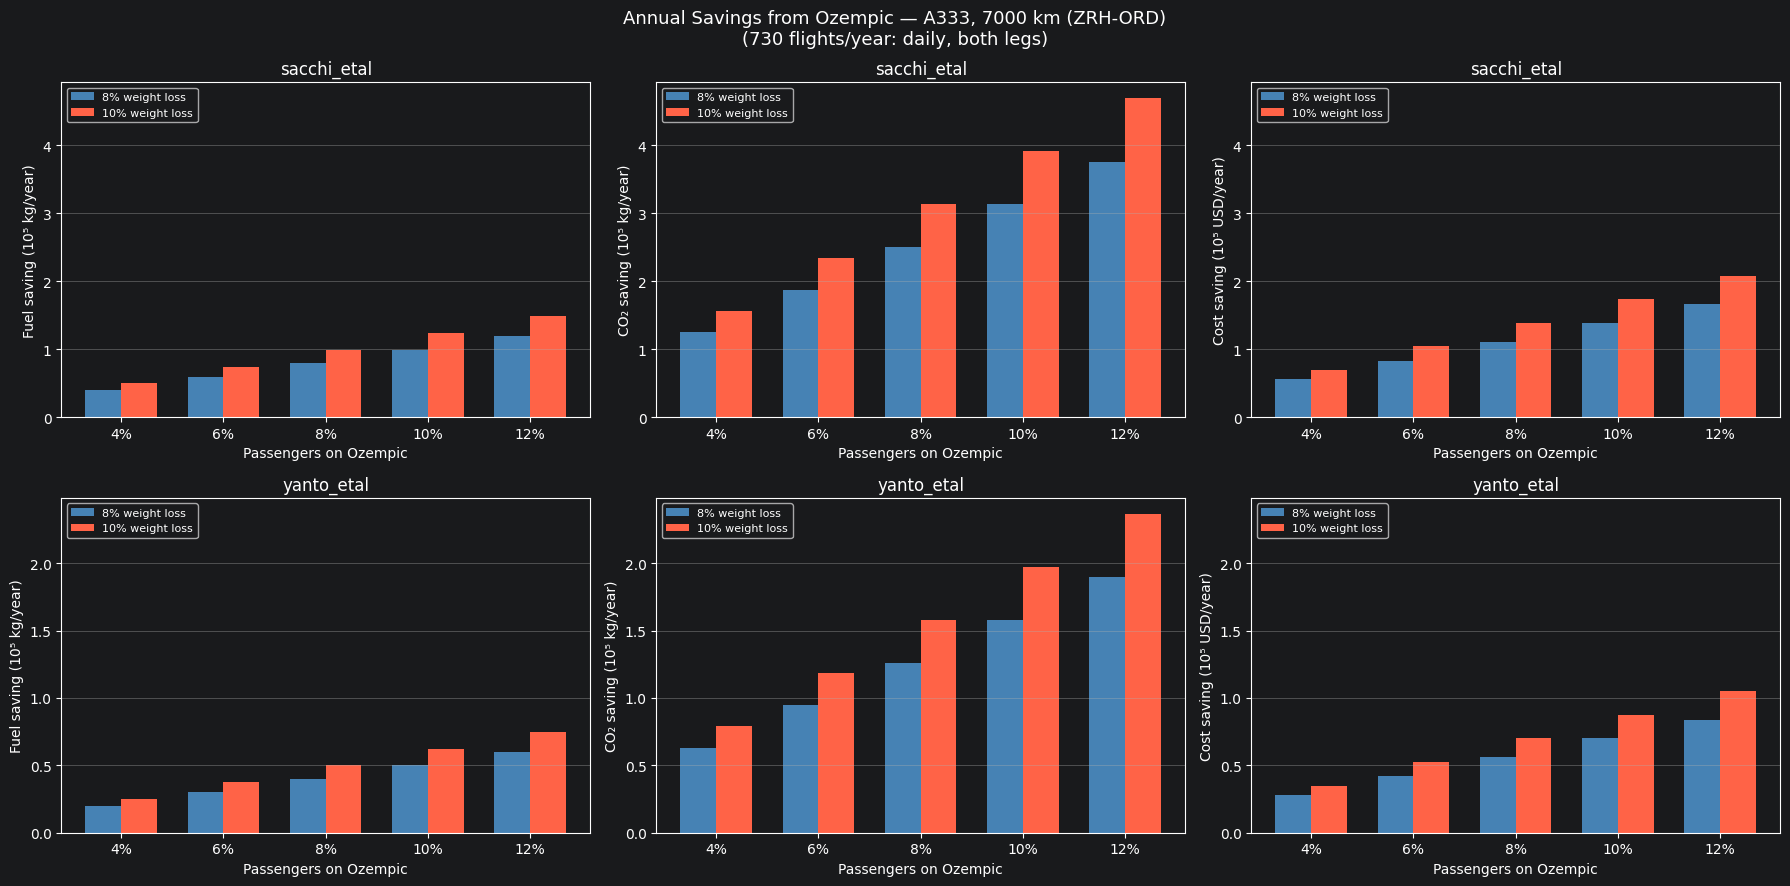

In [6]:
FLIGHTS_PER_YEAR = 2 * 365  # daily flight, both inbound and outbound legs
SCALE = 1e5

df_annual = df.copy()
for col in [
    "sacchi_fuel_diff_kg",
    "sacchi_co2_diff_kg",
    "sacchi_cost_diff_usd",
    "yanto_fuel_diff_kg",
    "yanto_co2_diff_kg",
    "yanto_cost_diff_usd",
]:
    df_annual[col] = df[col] * FLIGHTS_PER_YEAR / SCALE

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey="row")
fig.suptitle(
    f"Annual Savings from Ozempic — A333, 7000 km (ZRH-ORD)\n"
    f"({FLIGHTS_PER_YEAR} flights/year: daily, both legs)",
    fontsize=13,
)

for row_idx, (model, fuel_col, co2_col, cost_col) in enumerate(metrics):
    for col_idx, (metric, ylabel) in enumerate(
        [
            (fuel_col, "Fuel saving (10⁵ kg/year)"),
            (co2_col, "CO₂ saving (10⁵ kg/year)"),
            (cost_col, "Cost saving (10⁵ USD/year)"),
        ]
    ):
        ax = axes[row_idx][col_idx]
        for i, wl in enumerate(weightloss_coeffs):
            subset = df_annual[df_annual["weightloss_coeff"] == wl].sort_values(
                "people_on_ozempic"
            )
            ax.bar(
                x + (i - 0.5) * width,
                subset[metric].values,
                width,
                label=f"{int(wl * 100)}% weight loss",
                color=colors[i],
            )
        ax.set_title(f"{model}")
        ax.set_ylabel(ylabel)
        ax.set_xlabel("Passengers on Ozempic")
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.tick_params(labelleft=True)
        ax.legend(fontsize=8, loc="upper left")
        ax.grid(axis="y", linewidth=0.5)

plt.tight_layout()
plt.savefig("savings_annual.pdf", bbox_inches="tight")
plt.show()

In [7]:
# fuel burn reduction through GLP-1 medication
import pandas as pd
from jetfuelburn.reducedorder import yanto_etal, sacchi_etal
from jetfuelburn import ureg

CO2_FACTOR = 3.16  # kg CO2 per kg jet-A (IATA standard)

# FAA AC 120-27F carry-on allowance (personal item + carry-on bag)
CARRYON_KG = 7.3 * ureg.kg

# Flight-weighted mean body weights
# (pre-GLP1 values, sex x age group)
body_weights = {
    ("male", "18-35"): 87.34 * ureg.kg,
    ("male", "35-50"): 89.88 * ureg.kg,
    ("male", "50-65"): 88.86 * ureg.kg,
    ("male", "65-80"): 84.39 * ureg.kg,
    ("female", "18-35"): 73.59 * ureg.kg,
    ("female", "35-50"): 77.01 * ureg.kg,
    ("female", "50-65"): 78.74 * ureg.kg,
    ("female", "65-80"): 71.26 * ureg.kg,
}

# Total pax weight = body weight + carry-on (FAA AC 120-27F method)
total_weights = {k: v + CARRYON_KG for k, v in body_weights.items()}

# Fleet-wide mean (equal weighting across sex x age strata)
mean_pax_weight = sum(total_weights.values()) / len(total_weights)
print(f"Fleet-wide mean pax weight (body + carry-on): {mean_pax_weight.to('kg'):.1f}")

# GLP-1 delta (body weight only, carry-on unaffected)
delta_kg_per_pax = 0.557 * ureg.kg

# Fleet segments
fleet_segments = [
    {"name": "domestic_narrowbody", "acft": "A320", "R": 1850 * ureg.km, "seats": 162},
    {"name": "transcon_narrowbody", "acft": "A320", "R": 4100 * ureg.km, "seats": 162},
    {
        "name": "international_widebody",
        "acft": "B772",
        "R": 9000 * ureg.km,
        "seats": 280,
    },
]

# Sacchi models weight reduction as an equivalent fractional pax reduction
weight_reduction_fraction = (delta_kg_per_pax / mean_pax_weight).magnitude

records = []
for seg in fleet_segments:
    payload_base = seg["seats"] * mean_pax_weight
    payload_glp1 = payload_base - (seg["seats"] * delta_kg_per_pax)

    # yanto_etal: uses absolute payload
    fuel_yanto_base = yanto_etal.calculate_fuel_consumption(
        acft=seg["acft"],
        R=seg["R"],
        PL=payload_base,
    )
    fuel_yanto_glp1 = yanto_etal.calculate_fuel_consumption(
        acft=seg["acft"],
        R=seg["R"],
        PL=payload_glp1,
    )
    yanto_fuel_delta = (fuel_yanto_base - fuel_yanto_glp1).to("kg").magnitude
    yanto_co2_delta = yanto_fuel_delta * CO2_FACTOR

    # sacchi_etal: weight reduction expressed as equivalent reduction in pax count
    pax_base = seg["seats"]
    pax_glp1 = pax_base * (1 - weight_reduction_fraction)
    fuel_sacchi_base = sacchi_etal.calculate_fuel_consumption(
        year=2024,
        pax_max=seg["seats"],
        pax=pax_base,
        R=seg["R"],
    )
    fuel_sacchi_glp1 = sacchi_etal.calculate_fuel_consumption(
        year=2024,
        pax_max=seg["seats"],
        pax=pax_glp1,
        R=seg["R"],
    )
    sacchi_fuel_delta = (fuel_sacchi_base - fuel_sacchi_glp1).to("kg").magnitude
    sacchi_co2_delta = sacchi_fuel_delta * CO2_FACTOR

    records.append(
        {
            "segment": seg["name"],
            "aircraft": seg["acft"],
            "distance_km": seg["R"].magnitude,
            "seats": seg["seats"],
            "mean_pax_kg": round(mean_pax_weight.magnitude, 1),
            "yanto_fuel_base_kg": round(fuel_yanto_base.to("kg").magnitude, 1),
            "yanto_fuel_delta_kg": round(yanto_fuel_delta, 2),
            "yanto_co2_delta_kg": round(yanto_co2_delta, 2),
            "sacchi_fuel_base_kg": round(fuel_sacchi_base.to("kg").magnitude, 1),
            "sacchi_fuel_delta_kg": round(sacchi_fuel_delta, 2),
            "sacchi_co2_delta_kg": round(sacchi_co2_delta, 2),
        }
    )

df_step3 = pd.DataFrame(records)
print(df_step3.to_string(index=False))

Fleet-wide mean pax weight (body + carry-on): 88.7 kilogram
               segment aircraft  distance_km  seats  mean_pax_kg  yanto_fuel_base_kg  yanto_fuel_delta_kg  yanto_co2_delta_kg  sacchi_fuel_base_kg  sacchi_fuel_delta_kg  sacchi_co2_delta_kg
   domestic_narrowbody     A320         1850    162         88.7              6044.0                12.45               39.35               9849.6                 13.82                43.66
   transcon_narrowbody     A320         4100    162         88.7             10508.0                12.45               39.35              19447.3                 27.16                85.83
international_widebody     B772         9000    280         88.7             62714.7                61.76              195.16              77640.8                115.17               363.93
